# MCF7: Feature selection + Classifiers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pickle
import os

os.makedirs('../outputs/models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

## 1. Load data

The raw DropSeq files are stored **genes × cells** (rows = genes), so we transpose after loading to get the standard **cells × genes** matrix.

- `train_raw`: labelled cells (barcode encodes condition, e.g. `AAAAACCTATCG_Normoxia`)
- `test_raw`: anonymous cells — barcodes carry no label, predictions saved at the end.

In [2]:
train_raw = pd.read_csv('../data/DropSeq/MCF7_Filtered_Normalised_3000_Data_train.txt', sep=' ', index_col=0)
test_raw  = pd.read_csv('../data/DropSeq/MCF7_Filtered_Normalised_3000_Data_test_anonim.txt', sep=' ', index_col=0)

train_raw = train_raw.T
test_raw = test_raw.T

print('Train shape (cells x genes):', train_raw.shape)
print('Test shape  (cells x genes):', test_raw.shape)
print('Train sample cell names:', train_raw.index[:3].tolist())
print('Test  sample cell names:', test_raw.index[:3].tolist())



Train shape (cells x genes): (21626, 3000)
Test shape  (cells x genes): (5406, 3000)
Train sample cell names: ['AAAAACCTATCG_Normoxia', 'AAAACAACCCTA_Normoxia', 'AAAACACTCTCA_Normoxia']
Test  sample cell names: ['1', '2', '3']


## 2. Extract Labels

Labels are encoded as the last `_`-delimited token in each cell barcode (e.g. `AAAAACCTATCG_Normoxia` → `Normoxia`). The anonymous test set carries no label; we only predict on it.

`x_train` / `x_test` are the raw NumPy arrays passed to sklearn.

In [5]:
y_train = train_raw.index.str.split('_').str[-1].values

x_train = train_raw.values
x_test = test_raw.values

print('Train label distribution:', pd.Series(y_train).value_counts().to_dict())
print('Test cells (with no labels):', x_test.shape[0])

Train label distribution: {'Normoxia': 12705, 'Hypoxia': 8921}
Test cells (with no labels): 5406


## 3. Feature Selection

Two-stage dimensionality reduction, **fit on train only** to avoid data leakage:

1. **Variance threshold** (`threshold=0.01`): remove near-constant genes that carry no discriminative signal.
2. **Mutual information** (`mutual_info_classif`): rank surviving genes by their statistical dependency with the Hypoxia/Normoxia label; keep the top `N_TOP_GENES = 500`.

The same fitted transformers are applied to `x_test` without refitting.

In [6]:
var_filter = VarianceThreshold(threshold=0.01)
x_train_var = var_filter.fit_transform(x_train)
x_test_var = var_filter.transform(x_test)

print(f'Genes before variance filter: {x_train.shape[1]}')
print(f'Genes after  variance filter: {x_train_var.shape[1]}')

Genes before variance filter: 3000
Genes after  variance filter: 1125


In [7]:
N_TOP_GENES = 500

mi_scores = mutual_info_classif(x_train_var, y_train, random_state=42)
top_idx = np.argsort(mi_scores)[::-1][:N_TOP_GENES]

x_train_top = x_train_var[:, top_idx]
x_test_top = x_test_var[:, top_idx]

print(f'Genes after mutual info selection: {x_train_top.shape[1]}')

genes_after_var = train_raw.columns[var_filter.get_support()]
top_genes = genes_after_var[top_idx]
pd.Series(mi_scores[top_idx], index=top_genes).sort_values(ascending=False).to_csv('../outputs/MCF7_top_genes.csv', header=['mi_score'])
print('Saved: outputs/MCF7_top_genes_mi_scores.csv')

Genes after mutual info selection: 500
Saved: outputs/MCF7_top_genes_mi_scores.csv


**Visualising the top 20 genes by mutual information (MI)**  

This is a quick sanity-check: the bar chart shows the 20 most informative genes. High MI scores confirm that the selected features are genuinely predictive of oxygen condition.

C:\Users\marar\AppData\Local\Temp\ipykernel_23696\1018070375.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores[top_idx][:20], y=top_genes[:20], palette='viridis')


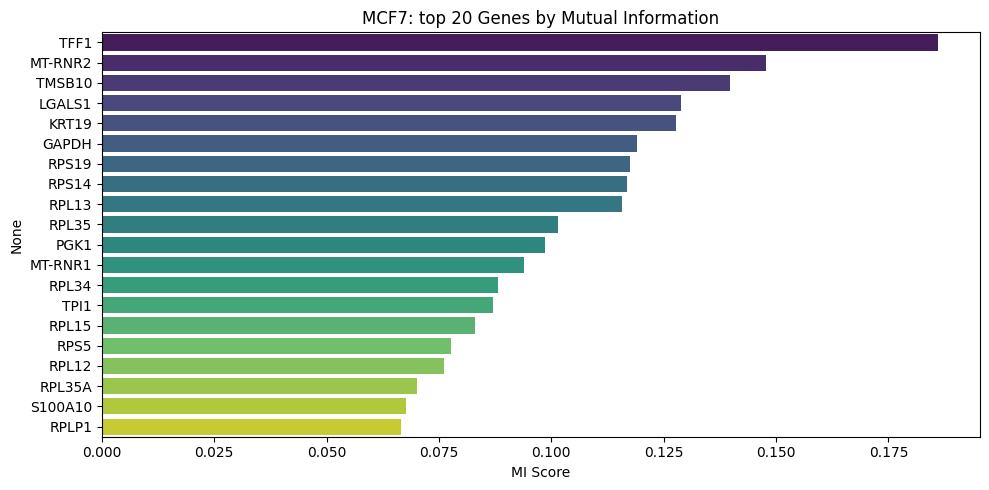

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores[top_idx][:20], y=top_genes[:20], palette='viridis')
plt.title('MCF7: top 20 Genes by Mutual Information')
plt.xlabel('MI Score')
plt.tight_layout()
plt.savefig('../outputs/figures/MCF7_top20_MI_genes.png', dpi=150)
plt.show()

## 4. Cross-validation on train set

We run 5-fold stratified cross-validation to compare all four classifier on `x_train_top` before committing to the full training.

Through stratification we ensure that each fold preserves the Hypoxia/Normoxia class ration. 

`random_state=42` is the usual seed  fixed for reproductibility.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                SVC(kernel='rbf', random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, x_train_top, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

LogisticRegression         mean=0.9767  std=0.0016
SVM                        mean=0.9807  std=0.0024
RandomForest               mean=0.9699  std=0.0018
GradientBoosting           mean=0.9703  std=0.0010


### CV accuracy distribution

Box plot of per-fodl accuracies for each classifier. Narrow boxes indicate stable performance across fold. Higher medians are preferred.

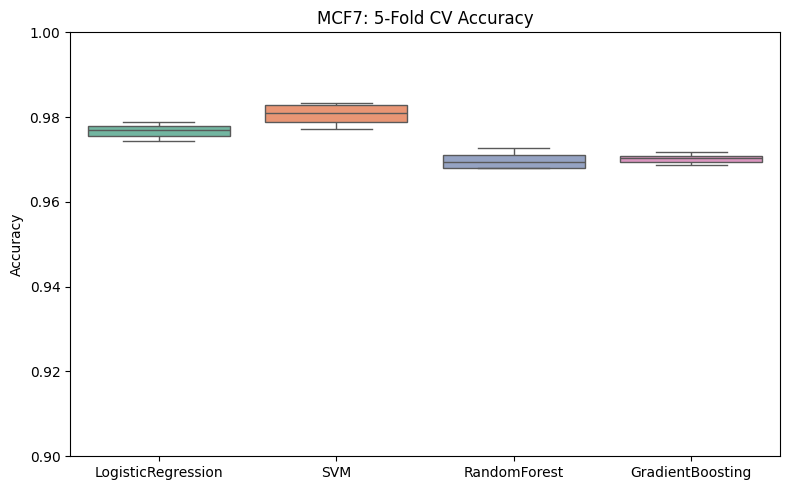

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=pd.DataFrame(cv_results), palette='Set2')
plt.title('MCF7: 5-Fold CV Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.90, 1.0)
plt.tight_layout()
plt.savefig('../outputs/figures/MCF7_cv_comparison.png', dpi=150)
plt.show()

## 5. Train on the full training set

Each model is retrained on the entire `x_train_top` to maximise the information available before predicting on the anonymous test set.

Fitted models are serialised with `pickle` to `outputs/models/MCF7_DropSeq_<ModelName>.pkl` for downstream use by the generalisation notebook.

In [20]:
trained_models = {}
for name, model in models.items():
    model.fit(x_train_top, y_train)
    trained_models[name] = model
    path = f'../outputs/models/MCF7_DropSeq_{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

Saved: ../outputs/models/MCF7_DropSeq_LogisticRegression.pkl
Saved: ../outputs/models/MCF7_DropSeq_SVM.pkl
Saved: ../outputs/models/MCF7_DropSeq_RandomForest.pkl
Saved: ../outputs/models/MCF7_DropSeq_GradientBoosting.pkl


## 6. Predict on anonymous test set

`BEST_MODEL_NAME` selects the classifier with the highest mean CV accuracy. Predictions are saved as a CSV with one row per cell:

| column | description |
|---|---|
| `cell` | cell barcode |
| `predicted_label` | `Hypoxia` or `Normoxia` |

In [18]:
BEST_MODEL_NAME = 'SVM'

best = trained_models[BEST_MODEL_NAME]
y_pred = best.predict(x_test_top)

pred_df = pd.DataFrame({
    'cell': test_raw.index,
    'predicted_label': y_pred
})

pred_df.to_csv('../outputs/MCF7_DropSeq_predictions.csv', index=False)

## 7. Random forest feature importance

Random Forest exposes `feature_importances_` (mean decrease in impurity). These are complementary to the MI scores from §3: MI measures marginal relevance to the label, while RF importance reflects the gene's contribution inside the trained ensemble.

The top-20 bar chart and the full ranked list (`MCF7_RF_feature_importance.csv`) are saved for biological interpretation.

C:\Users\marar\AppData\Local\Temp\ipykernel_23696\87110443.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_series.values[:20], y=importance_series.index[:20], palette='magma')


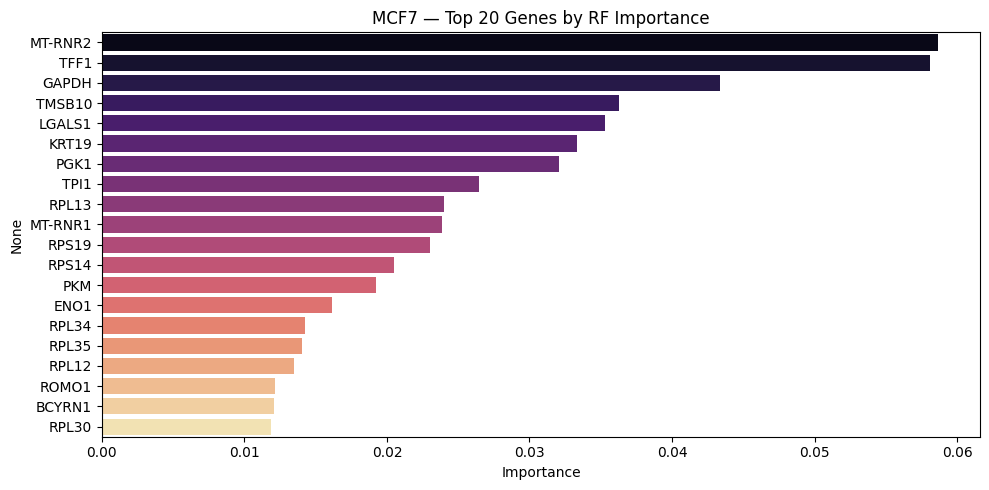

In [21]:
rf = trained_models['RandomForest']
importance_series = pd.Series(rf.feature_importances_, index=top_genes).sort_values(ascending=False)
importance_series.to_csv('../outputs/MCF7_RF_feature_importance.csv', header=['importance'])

plt.figure(figsize=(10, 5))
sns.barplot(x=importance_series.values[:20], y=importance_series.index[:20], palette='magma')
plt.title('MCF7 — Top 20 Genes by RF Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/figures/MCF7_RF_feature_importance.png', dpi=150)
plt.show()

## Summary

**Cross-validation results (5-fold, DropSeq MCF7):**

| Model | Mean Accuracy | Std |
|---|---|---|
| Logistic Regression | 0.9767 | 0.0016 |
| SVM (RBF) | 0.9807 | 0.0024 |
| Random Forest | 0.9699 | 0.0018 |
| Gradient Boosting | 0.9703 | 0.0010 |

**Best model: SVM (RBF)**: selected based on highest mean CV accuracy.

**Saved files:**
- `outputs/models/MCF7_DropSeq_*.pkl` -> all 4 trained models
- `outputs/MCF7_DropSeq_predictions.csv` -> predictions on anonymous test set
- `outputs/MCF7_top_genes.csv` -> top 500 genes by mutual information score
- `outputs/MCF7_RF_feature_importance.csv` -> Random Forest feature importances (for biological interpretation)
- `outputs/figures/MCF7_*.png` -> all plots